# 5. CNN(Convolutional Neural Network)

> 이 노트북은 강의 자료에서 자동 변환되었습니다.  
> Google Colab에서 `런타임 > 런타임 유형 변경 > GPU`로 설정 후 실행하세요.


# 5. CNN(Convolutional Neural Network)

## 학습 목표
1. CNN의 핵심 구조(Convolution, Pooling, FC)를 설명할 수 있다
2. Conv2d의 주요 파라미터(in_channels, out_channels, kernel_size, stride, padding)를 이해할 수 있다
3. Feature Map이 CNN을 통과하며 변환되는 과정을 시각화로 확인할 수 있다
4. CNN을 이용한 MNIST 숫자 인식 모델을 학습하고 평가할 수 있다
5. 학습된 모델을 저장하고 Flask 웹 서비스로 배포할 수 있다

## 진행 순서

1. [CNN 개요](#part1) - Linear Layer 문제점, Feature Extraction, CNN 구조, Layer별 Feature
2. [Convolution 연산](#part2) - 이미지 필터, Filter/kernel, Conv2d 파라미터, Weight 시각화
3. [다중 채널, Stride, Padding, Pooling](#part3) - 공간 해상도를 결정하는 세 가지 요소
4. [분류기 구조 요소](#part4) - Dropout, Linear, Softmax, 출력 크기 계산
5. [MNIST 모델 학습과 평가](#part5) - 구글 드라이브 연결, 모델 생성, 학습, 평가
6. [모델 활용과 웹 서비스](#part6) - 모델 사용하기, Flask 웹 서비스
7. [통합 정리](#part7) - 복습 문제와 심화 과제

---

## 1. CNN 개요

**학습목표**: Linear Layer만으로 이미지 분류가 어려운 이유와 CNN 구조의 기본 원리를 설명할 수 있다.

### Linear Layer 기반의 Image Classification 시 문제점
![](./img/cnn/cnn001.png)

### Feature Extraction 기반의 Image 분류 매커니즘
![](./img/cnn/cnn002.png)

### Deep Learning CNN 구조
![](./img/cnn/cnn003.webp)

### CNN Layer 별 Feature 학습
![](./img/cnn/cnn004.png)

**핵심**: Linear Layer만으로는 이미지의 공간적 구조를 활용하기 어렵다. CNN은 Convolution을 통해 이미지의 특징을 자동으로 추출하고, 낮은 층에서는 단순한 특징을, 높은 층에서는 복잡한 특징을 학습한다.

---

## 2. Convolution 연산

**학습목표**: Conv Filter가 이미지를 슬라이딩하며 특징을 추출하는 원리와 Conv2d의 주요 파라미터를 이해할 수 있다.

### 이미지 필터
![](./img/cnn/cnn005.png)

### Convolution Layer Filter(kernel)
필터는 전체 너비를 파싱할 때까지 특정 보폭 값으로 오른쪽으로 이동합니다.
계속해서 전체 이미지가 탐색될 때까지 이 과정을 반복해서 처리합니다.
Kernel Size(크기)라고 하면 면적(가로x세로)을 의미하며 가로와 세로는 서로 다를 수 있지만 보통은 일치 합니다. (3 X 3, 5 X 5, 7 X 7)
Deep Learning CNN은 Filter값을 사용자가 직접 만들거나 선택할 필요는 없고, Deep Learning Network 구성을 통해 이미지 분류 등의 목적에 부합하는 최적의 filter 값을 학습을 통해 스스로 최적화 합니다.

![](./img/cnn/cnn006.gif)

### Conv2d 파라미터 이해

PyTorch에서 `nn.Conv2d`의 주요 파라미터는 다음과 같습니다.

| 파라미터 | 의미 |
|---------|------|
| `in_channels` | 받게 될 channel의 갯수 (흑백=1, RGB=3) |
| `out_channels` | 보내고 싶은 channel의 갯수 (= 필터 갯수) |
| `kernel_size` | 만들고 싶은 kernel(weight)의 사이즈 |
| `stride` | 필터가 이동하는 간격 |


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Conv2d Layer 생성: 1채널 입력 → 20채널 출력, 5x5 커널
layer = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
layer

Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))

### Convolution Weight 시각화

Conv Layer의 weight는 학습 가능한 상태이므로 `detach()`로 gradient 그래프에서 분리한 뒤 numpy로 변환해야 합니다.


torch.Size([20, 1, 5, 5])


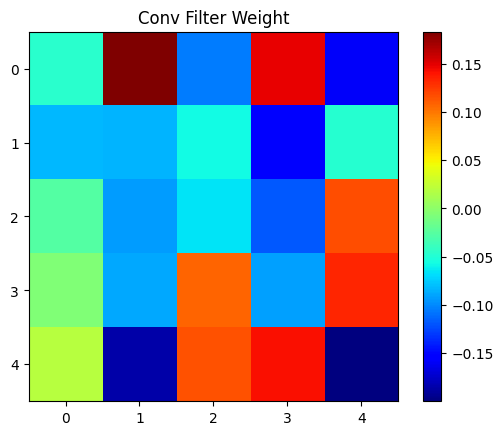

In [2]:
# weight shape 확인: (out_channels, in_channels, H, W)
weight = layer.weight
print(weight.shape)  # torch.Size([20, 1, 5, 5])

# detach()로 gradient 그래프에서 분리 후 numpy 변환
weight = weight.detach().numpy()

# 첫 번째 필터 시각화
plt.imshow(weight[0, 0, :, :], 'jet')
plt.colorbar()
plt.title('Conv Filter Weight')
plt.show()

### Conv Layer Input → Weight → Output 비교 시각화

MNIST 이미지 1장을 Conv Layer에 통과시켜 입력/필터/출력을 나란히 비교합니다.


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


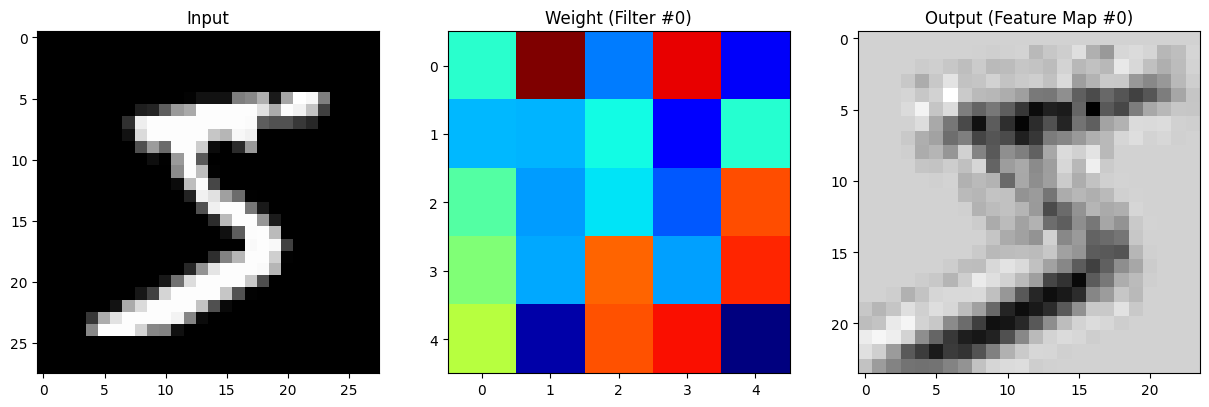

In [3]:
from torchvision import datasets, transforms

# MNIST 이미지 1장 로드
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('dataset', train=True, download=True,
                   transform=transforms.Compose([transforms.ToTensor()])),
    batch_size=1)
image, label = next(iter(train_loader))

# Conv Layer 통과
output_data = layer(image)
output = output_data.data.cpu().numpy()
image_arr = image.numpy()

# Input / Weight / Output 3분할 비교
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title('Input')
plt.imshow(np.squeeze(image_arr), 'gray')
plt.subplot(132)
plt.title('Weight (Filter #0)')
plt.imshow(weight[0, 0, :, :], 'jet')
plt.subplot(133)
plt.title('Output (Feature Map #0)')
plt.imshow(output[0, 0, :, :], 'gray')
plt.show()

**핵심**: Conv Filter는 이미지를 슬라이딩하며 특징을 추출한다. Deep Learning CNN은 최적의 필터 값을 학습을 통해 스스로 찾는다.

---

## 3. 다중 채널, Stride, Padding, Pooling

**학습목표**: Stride, Padding, Pooling의 역할과 출력 Feature Map 크기에 미치는 영향을 이해할 수 있다.

### 다중 채널 일때 Convolution Layer
여러 채널(예: RGB)이 있는 이미지의 경우 커널은 입력 이미지의 깊이와 동일한 깊이입니다.
Kn과 In 스택([K1, I1]; [K2, I2]; [K3, I3]) 사이에서 행렬 곱셈이 수행되고 모든 결과를 바이어스와 합산하여 한 개의 깊이 채널로 압축된 복잡한 특징 출력을 얻는다.

![](./img/cnn/cnn007.webp)
![](./img/cnn/cnn008.gif)
![](./img/cnn/cnn008.png)

### Stride
stride는 입력 데이터(원본 image또는 입력 feature map)에 Conv Filter를 적용할 때 Sliding Window가 이동하는 간격을 의미하고,
기본은 1이지만, 2를(2 pixel 단위로 Sliding window 이동) 적용하여 입력 feature map 대비 출력 feature map의 크기를 대략 절반으로 줄일수 있습니다.
stride를 키우면 공간적인 feature 특성을 손실할 가능성이 높아지지만, 이것이 중요 feature들의 손실을 반드시 의미하지는 않습니다.
오히려 불필요한 특성을 제거하는 효과를 가져 올 수 있습니다.
또한 Convolution 연산 속도가 향상됩니다.

Stride = 1
![](./img/cnn/cnn010.gif)

Stride = 2
![](./img/cnn/cnn009.gif)

### Padding
Filter를 적용하여 Conv 연산 수행 시 출력 Feature Map이 입력 Feature Map 대비 계속적으로 작아지는 것을 막기 위해 적용합니다.
![](./img/cnn/cnn011.png)

### Pooling
Conv 적용된 Feature map의 일정 영역 별로 하나의 값을 추출하여(주로 Max 또는 Average 적용) Feature map의 사이즈를 줄입니다.(sub sampling).
일반적으로 Pooling 크기와 Stride를 동일하게 부여하여 모든 값이 한번만 처리 될 수 있도록 합니다.
일정 영역에서 가장 큰 값 또는 평균 값을 추출하므로 위치의 변화에 따른 feature 값의 변화를 일정 수준 중화 시킬 수 있습니다.
보통은 Conv->ReLU activation 들을 연속 적용 후 Feature Map에 Pooling 적용합니다.
![](./img/cnn/cnn012.png)

### Pooling 시각화

`F.max_pool2d`는 입력을 넣고 kernel 사이즈와 stride를 순서대로 지정합니다.
MaxPool Layer는 **학습할 weight가 없기 때문에** 바로 `numpy()`로 변환할 수 있습니다.


입력: torch.Size([1, 1, 28, 28]) → 출력: torch.Size([1, 1, 14, 14])


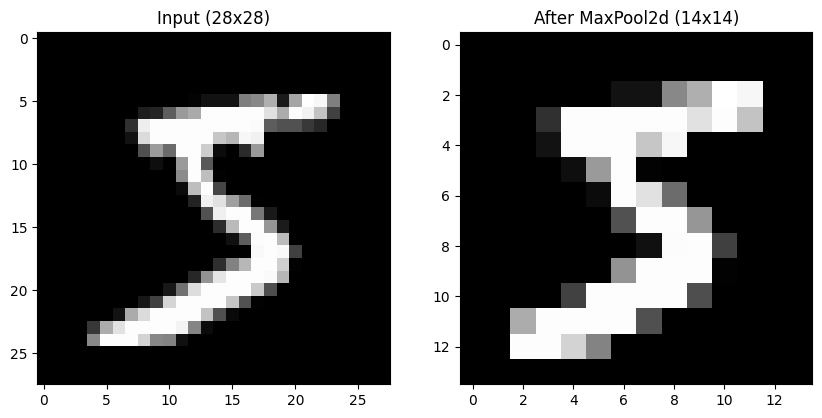

In [4]:
# MaxPooling 적용: 2x2 커널, stride 2
pool = F.max_pool2d(image, 2, 2)
print(f"입력: {image.shape} → 출력: {pool.shape}")

# Input vs Pooled Output 비교 시각화
pool_arr = pool.numpy()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Input (28x28)")
plt.imshow(np.squeeze(image_arr), 'gray')
plt.subplot(122)
plt.title('After MaxPool2d (14x14)')
plt.imshow(np.squeeze(pool_arr), 'gray')
plt.show()

**핵심**: Stride는 필터 이동 간격, Padding은 출력 크기 유지, Pooling은 Feature Map 축소를 담당한다. 이 세 요소의 조합이 CNN의 공간 해상도를 결정한다.

---

## 4. 분류기 구조 요소

**학습목표**: Dropout, Linear Layer, Softmax의 역할과 출력 Feature Map 크기 계산 방법을 이해할 수 있다.

### Dropout
Fully Connected Layer의 너무 촘촘한 연결로 인한 많은 파라미터(weight) 생성은 오히려 오버 피팅을 가져 올 수 있음.
Dropout을 통해 Layer간 연결을 줄일 수 있으며 오버 피팅 개선을 가져 올 수 있음.
![](./img/cnn/cnn013.png)

### Linear Layer 시각화

`nn.Linear`는 2D 이미지를 직접 받을 수 없으므로, `.view()`로 1D로 펼쳐야(flatten) 합니다.


변환 전: torch.Size([1, 1, 28, 28]) → 변환 후: torch.Size([1, 784])
Linear 출력: torch.Size([1, 10])


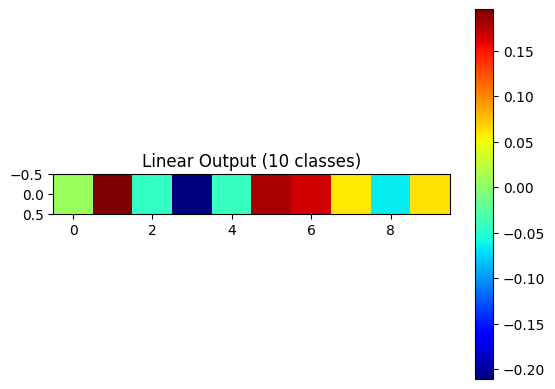

In [5]:
# 28x28 이미지 → 784 길이의 1D 벡터로 변환
flatten = image.view(1, 28 * 28)
print(f"변환 전: {image.shape} → 변환 후: {flatten.shape}")

# Linear Layer 통과: 784 → 10 (클래스 수)
lin = nn.Linear(784, 10)(flatten)
print(f"Linear 출력: {lin.shape}")

# Linear 출력 시각화 (10개 클래스에 대한 점수)
plt.imshow(lin.detach().numpy(), 'jet')
plt.colorbar()
plt.title('Linear Output (10 classes)')
plt.show()

### Softmax 시각화

Linear Layer의 출력을 확률로 변환하는 것이 Softmax입니다.
결과를 numpy로 꺼내기 위해서는 `torch.no_grad()`로 gradient 계산을 비활성화해야 합니다.


In [6]:
with torch.no_grad():
    flatten = image.view(1, 28 * 28)
    lin = nn.Linear(784, 10)(flatten)
    softmax = F.softmax(lin, dim=1)

print(softmax)
print(f"확률 합계: {np.sum(softmax.numpy())}")  # 1.0

tensor([[0.1045, 0.0924, 0.0972, 0.0936, 0.0871, 0.1002, 0.1205, 0.0993, 0.1014,
         0.1038]])
확률 합계: 1.0


> Softmax 출력값의 합은 항상 1.0이 됩니다. 각 값은 해당 클래스일 확률을 의미합니다.

### conv 연산 적용 후 출력 피처맵의 크기(size) 구하기
![](./img/cnn/cnn014.png)

#### Stride가 1이고, padding이 없는 경우
![](./img/cnn/cnn015.png)

#### Stride가 1이고, padding이 1인 경우
![](./img/cnn/cnn016.png)

#### Stride가 2이고, padding이 없는 경우
![](./img/cnn/cnn017.png)

#### Stride가 1이고, padding이 1인 경우
![](./img/cnn/cnn018.png)

**핵심**: Feature Extraction(Conv+Pool) 이후 Flatten → Linear → Softmax로 분류를 수행한다. Dropout은 과적합을 방지하고, Softmax는 출력을 확률로 변환한다.

---

## 5. MNIST 모델 학습과 평가

**학습목표**: CNN 모델을 정의하고 MNIST 데이터셋으로 학습·평가한 뒤 모델을 저장할 수 있다.

### 구글 드라이브와 연결

데이터 파일 및 결과 파일을 구글 드라이브에 저장하기 위해 구글 드라이브를 연결


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


저장할 경로를 미리 선언


In [8]:
root_dir = '/content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist'

### 모델 생성

필요한 라이브러리 import


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

현재 gpu를 사용할 수 있는지 확인


In [10]:
is_cuda = torch.cuda.is_available()
is_cuda

False

gpu 사용 여부에 따라 device에 값을 셋팅


In [11]:
device = torch.device('cuda' if is_cuda else 'cpu')
device

device(type='cpu')

하이퍼 파라미터 값을 설정


In [12]:
batch_size = 50
epoch_num = 15
learning_rate = 0.0001

학습과 평가에 사용할 MNIST 데이터를 다운로드 받아서 저장


In [13]:
train_data = datasets.MNIST(root=root_dir+'/data',
                            train=True,
                            download = True,
                            transform=transforms.ToTensor())
test_data = datasets.MNIST(root=root_dir+'/data',
                            train=False,
                            transform=transforms.ToTensor())

다운로드 받은 데이터 건수 확인


In [14]:
print(len(train_data),len(test_data))

60000 10000


다운로드 받은 데이터의 타입 확인


In [15]:
print(type(train_data))

<class 'torchvision.datasets.mnist.MNIST'>


이미지와 레이블 저장 형태 확인


In [17]:
image,label = train_data[0]
print(label)
print(image.shape)

5
torch.Size([1, 28, 28])


이미지 출력


In [ ]:
plt.imshow(image.squeeze(),cmap='gray')

모델에 배치 사이즈 만큼 읽어서 제공할 DataLoader 생성


In [18]:
train_loader = torch.utils.data.DataLoader(dataset=train_data,
                                           batch_size=batch_size,
                                           shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                           batch_size=batch_size,
                                           shuffle = True)

DataLoader 로더해서 형태 파악


In [19]:
first_batch = train_loader.__iter__().__next__()

print(type(first_batch))
print(len(first_batch))

print(len(first_batch))
print(first_batch[0].shape)
print(first_batch[1].shape)

<class 'list'>
2
2
torch.Size([50, 1, 28, 28])
torch.Size([50])


name            | type                      | size
num of batch    |                           | 1200
first_batch     | <class 'list'>            | 2
first_batch[0]  | <class 'torch.Tensor'>    | torch.Size([50, 1, 28, 28])
first_batch[1]  | <class 'torch.Tensor'>    | torch.Size([50])


### nn과 nn.functional의 차이

| 구분 | `nn` (예: `nn.Conv2d`) | `nn.functional` (예: `F.relu`) |
|------|----------------------|-------------------------------|
| 학습 파라미터 | **있음** (weight, bias 포함) | **없음** |
| 사용 위치 | `__init__`에서 정의 | `forward`에서 호출 |
| 예시 | `nn.Conv2d`, `nn.Linear`, `nn.Dropout2d` | `F.relu`, `F.max_pool2d`, `F.log_softmax` |

> 간단히 정리하면: `nn`은 학습 파라미터가 담긴 레이어, `nn.functional`은 학습 파라미터가 없는 연산 함수입니다.

모델 정의


In [20]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

모델 생성및 옵티마이저, 오차함수 생성


In [ ]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(),lr = learning_rate)
criterion = nn.CrossEntropyLoss()

print(model)

### 모델 학습

생성된 모델 학습모드로 설정하고 학습 진행


In [ ]:
model.train()
i = 0
for epoch in range(epoch_num):
  for data, target in train_loader:
    data = data.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output,target)
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
      print(f"train step:{i}\tloss:{loss.item()}")
    i += 1


### 모델 평가 및 모델 저장

테스트 데이터로 모델 평가


In [ ]:
model.eval()
correct = 0
for data, target in test_loader:
  data = data.to(device)
  target = target.to(device)
  output = model(data)
  prediction = output.data.max(1)[1]
  correct += prediction.eq(target.data).sum()

결과값의 형태 파악


In [ ]:
print(output.shape)

print(output.max(1))

정확도 계산해서 출력


In [ ]:
print(100*correct/len(test_loader.dataset))

모델 저장


In [ ]:
torch.save(model.state_dict(),root_dir+'/model/mnist_cnn.pt')

**핵심**: Conv → ReLU → Conv → ReLU → Pool → Dropout → FC → Softmax 구조로 MNIST를 학습한다. best accuracy 기준으로 모델을 저장하여 이후 활용할 수 있다.

---

